In [2]:
import pandas as pd
from textblob import TextBlob

# 1. The dataset extracted directly from the Barbie (2023) FYP thesis
thesis_data = {
    'Character': [
        'Ken', 
        'Ken', 
        'Ken', 
        'Ken', 
        'Ken', 
        'Barbie', 
        'Barbie', 
        'Barbie', 
        'Barbie', 
        'Barbie'
    ],
    'Script_Quote': [
        "No, you failed me! Out there, I was somebody! I walked down the street, and people respected me just for WHO I AM.",
        "MEN RULED THE WORLD!",
        "I feel so stupid. I look SO stupid. I LOOK SO STUPID!!!!",
        "I hate it when people think. I’m so bored!",
        "I’m not getting any of that. I feel appreciated but not ogled.",
        "But I love women, and I want to help them.",
        "I feel kind of ill at ease; I don't even know the word for it...",
        "This is the lowest I’ve ever been. Emotionally AND physically.",
        "Women hold all major positions of power, control all the money, basically everything men do in your world, women do in ours.",
        "It is the best day ever!"
    ],
    'Thesis_Coding': [
        'Affect: Unhappiness (F1)', 
        'Affect: Happiness (F1)', 
        'Judgement: Capacity (F6)', 
        'Appreciation: Reaction (F10)', 
        'Appreciation: Valuation (F12)',
        'Affect: Happiness (F1)', 
        'Affect: Insecurity (F2)', 
        'Affect: Unhappiness (F1)', 
        'Judgement: Capacity (F6)', 
        'Appreciation: Reaction (F10)'
    ]
}

# 2. Convert the raw dictionary into a structured Pandas DataFrame
df = pd.DataFrame(thesis_data)

# 3. Display the table to ensure it loaded correctly
print(df)

  Character                                       Script_Quote  \
0       Ken  No, you failed me! Out there, I was somebody! ...   
1       Ken                               MEN RULED THE WORLD!   
2       Ken  I feel so stupid. I look SO stupid. I LOOK SO ...   
3       Ken         I hate it when people think. I’m so bored!   
4       Ken  I’m not getting any of that. I feel appreciate...   
5    Barbie         But I love women, and I want to help them.   
6    Barbie  I feel kind of ill at ease; I don't even know ...   
7    Barbie  This is the lowest I’ve ever been. Emotionally...   
8    Barbie  Women hold all major positions of power, contr...   
9    Barbie                           It is the best day ever!   

                   Thesis_Coding  
0       Affect: Unhappiness (F1)  
1         Affect: Happiness (F1)  
2       Judgement: Capacity (F6)  
3   Appreciation: Reaction (F10)  
4  Appreciation: Valuation (F12)  
5         Affect: Happiness (F1)  
6        Affect: Insecurity 

In [ ]:
from typing import Any

# 1. Build a custom mini-machine to score the text
def calculate_emotion(text: str) -> float:
    # ensure input is treated as string for TextBlob and return a float polarity
    return float(TextBlob(str(text)).sentiment.polarity)

# 2. Apply the machine to our quotes and save it in a new column
df['Machine_Score'] = df['Script_Quote'].apply(calculate_emotion)

# 3. Display the updated table to compare the results
print(df)

  Character                                       Script_Quote  \
0       Ken  No, you failed me! Out there, I was somebody! ...   
1       Ken                               MEN RULED THE WORLD!   
2       Ken  I feel so stupid. I look SO stupid. I LOOK SO ...   
3       Ken         I hate it when people think. I’m so bored!   
4       Ken  I’m not getting any of that. I feel appreciate...   
5    Barbie         But I love women, and I want to help them.   
6    Barbie  I feel kind of ill at ease; I don't even know ...   
7    Barbie  This is the lowest I’ve ever been. Emotionally...   
8    Barbie  Women hold all major positions of power, contr...   
9    Barbie                           It is the best day ever!   

                   Thesis_Coding  Machine_Score  
0       Affect: Unhappiness (F1)      -0.468403  
1         Affect: Happiness (F1)       0.000000  
2       Judgement: Capacity (F6)      -0.866667  
3   Appreciation: Reaction (F10)      -0.712500  
4  Appreciation: Valuat

C:\Users\Faithlynn Bernice\AppData\Local\Temp\ipykernel_10308\3484642071.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


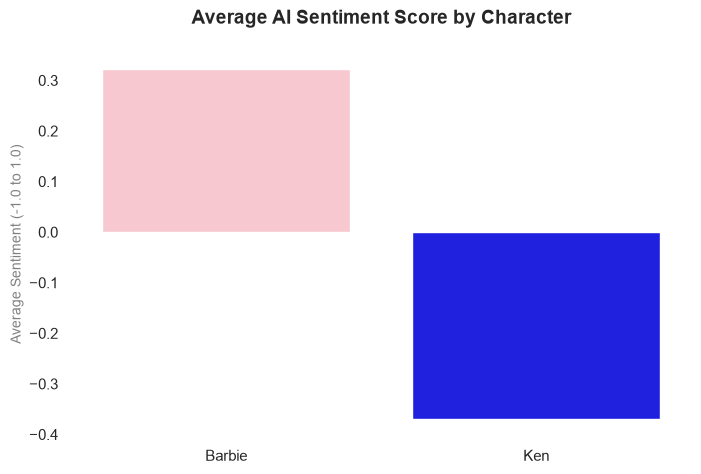

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average sentiment score for each character
avg_scores = df.groupby('Character')['Machine_Score'].mean().reset_index()

# 2. Set up a clean, minimalist canvas
sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(8, 5))

# 3. Define the brand colors and plot the bar chart
custom_colors = {"Ken": "blue", "Barbie": "pink"} 

ax = sns.barplot(
    data=avg_scores, 
    x='Character', 
    y='Machine_Score', 
    palette=custom_colors
)

# 4. Strip away heavy borders for an elegant aesthetic
sns.despine(left=True, bottom=True)
ax.tick_params(left=False, bottom=False)

# 5. Add clean typography for the titles
plt.title('Average AI Sentiment Score by Character', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Average Sentiment (-1.0 to 1.0)', fontsize=10, color='gray')
plt.xlabel('') 

# 6. Output the final graphic
plt.show()

C:\Users\Faithlynn Bernice\AppData\Local\Temp\ipykernel_10308\3021143107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


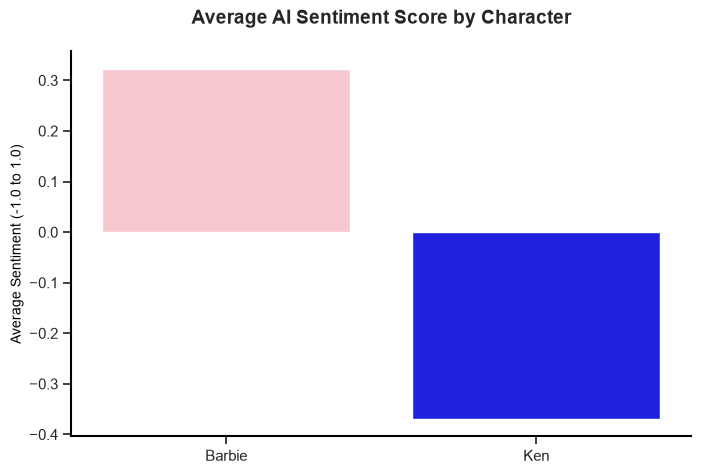

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average sentiment score for each character
avg_scores = df.groupby('Character')['Machine_Score'].mean().reset_index()

# 2. Set up a clean canvas
sns.set_theme(style="white", context="notebook")
plt.figure(figsize=(8, 5))

# 3. Define the brand colors and plot the bar chart
custom_colors = {"Ken": "blue", "Barbie": "pink"} 

ax = sns.barplot(
    data=avg_scores, 
    x='Character', 
    y='Machine_Score', 
    palette=custom_colors
)

# 4. Create clear X and Y axis lines (Removing only top and right)
sns.despine(top=True, right=True, left=False, bottom=False)

# 5. Make the axis lines thicker and black for high visibility
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1.5)

# Keep the tick marks visible on the axes
ax.tick_params(left=True, bottom=True)

# 6. Add clean typography for the titles
plt.title('Average AI Sentiment Score by Character', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Average Sentiment (-1.0 to 1.0)', fontsize=10, color='black')
plt.xlabel('') 

# 7. Output the final graphic
plt.show()